# 07 - EDA Integrado Pre-Modelado

## Hipotesis iniciales

1. El dataset cliente-mes integrado ya permite contrastar senales de cliente, facturacion, red, soporte y encuestas en una unica tabla.
2. Las familias mas prometedoras deberian aparecer en correlaciones, diferencias por segmentos o rankings de variables antes del modelado.
3. La clase churn mensual sera minoritaria, por lo que accuracy no sera una metrica suficiente.
4. La revision integrada debe funcionar como checklist anti-leakage antes de entrenar modelos.
5. Si las variables temporales estan bien construidas, el dataset deberia poder separarse con validacion temporal y sin duplicados cliente-mes.

## Que se va a contrastar

- Tamano, cobertura, clientes, meses y calidad estructural del dataset integrado.
- Distribucion del target y evolucion mensual del churn.
- Numero de variables por familia y variables numericas mas asociadas a churn futuro.
- Checks de leakage, duplicados y consistencia basica para pasar a modelado.


In [2]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Set2')
pd.options.display.float_format = '{:,.3f}'.format

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / 'data').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED = PROJECT_ROOT / 'data' / 'processed'
MODELING = PROJECT_ROOT / 'data' / 'modeling'
REPORTS = PROJECT_ROOT / 'reports'

df = pd.read_csv(MODELING / 'churn_modeling_dataset.csv', parse_dates=['fecha'])
quality = pd.read_csv(MODELING / 'modeling_quality_report.csv')


In [3]:
display(quality)
print('Shape:', df.shape)
print('Clientes:', df['cliente_id'].nunique())
print('Meses:', df['fecha'].nunique(), df['fecha'].min(), df['fecha'].max())
display(df['churn_t_plus_1'].value_counts(normalize=True).mul(100).round(3))


,metric,value
0,filas,311987
1,columnas,246
2,clientes_unicos,9982
3,mes_min,2023-01-01 00:00:00
4,mes_max,2025-11-01 00:00:00
5,target_nulos,0
6,target_fuera_catalogo,0
7,duplicados_cliente_mes,0
8,columnas_prohibidas_presentes,NaN
9,tasa_churn_t_plus_1,0.00635282880376426


Shape: (311987, 246)
Clientes: 9982
Meses: 35 2023-01-01 00:00:00 2025-11-01 00:00:00


churn_t_plus_1
0   99.365
1    0.635
Name: proportion, dtype: float64

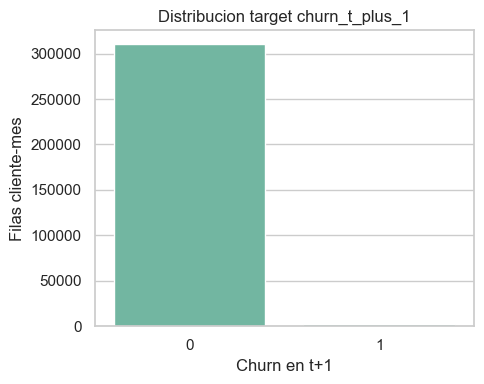

In [4]:
plt.figure(figsize=(5, 4))
sns.countplot(data=df, x='churn_t_plus_1')
plt.title('Distribucion target churn_t_plus_1')
plt.xlabel('Churn en t+1')
plt.ylabel('Filas cliente-mes')
plt.tight_layout()
plt.show()


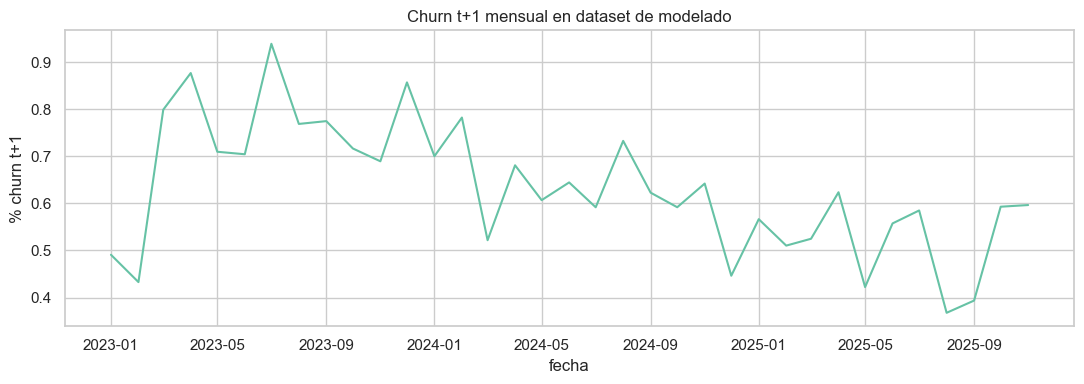

In [5]:
monthly = df.groupby('fecha', as_index=False).agg(churn_rate=('churn_t_plus_1','mean'), filas=('cliente_id','count'))
monthly['churn_rate'] *= 100
plt.figure(figsize=(11, 4))
sns.lineplot(data=monthly, x='fecha', y='churn_rate')
plt.title('Churn t+1 mensual en dataset de modelado')
plt.ylabel('% churn t+1')
plt.tight_layout()
plt.show()


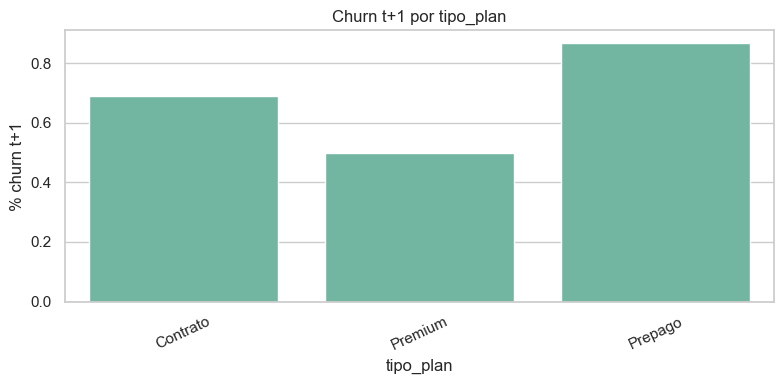

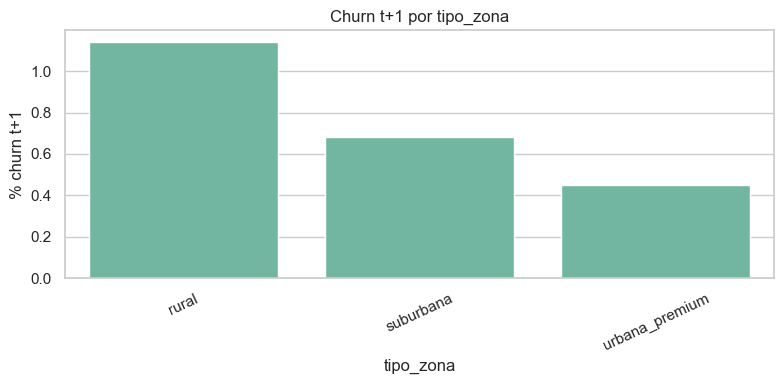

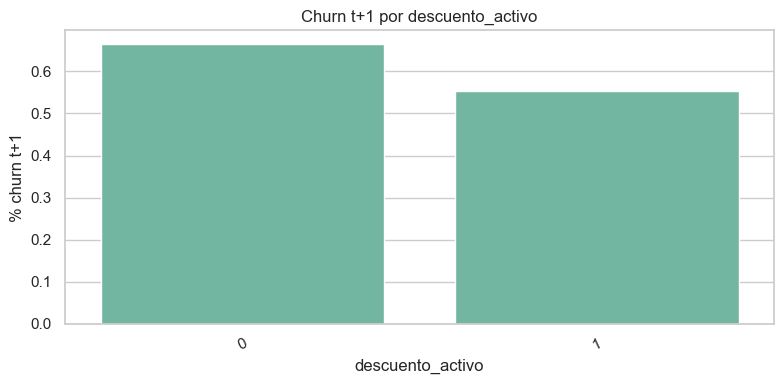

In [6]:
for col in ['tipo_plan', 'tipo_zona', 'descuento_activo']:
    rates = df.groupby(col)['churn_t_plus_1'].agg(n='count', churn_rate='mean').reset_index()
    rates['churn_rate'] *= 100
    plt.figure(figsize=(8, 4))
    sns.barplot(data=rates, x=col, y='churn_rate')
    plt.title(f'Churn t+1 por {col}')
    plt.ylabel('% churn t+1')
    plt.xticks(rotation=25)
    plt.tight_layout()
    plt.show()


In [7]:
feature_families = {
    'cliente': [c for c in df.columns if not c.startswith(('fact_', 'red_', 'soporte_', 'encuestas_')) and c not in ['cliente_id','fecha','churn_t_plus_1']],
    'facturacion': [c for c in df.columns if c.startswith('fact_')],
    'red': [c for c in df.columns if c.startswith('red_')],
    'soporte': [c for c in df.columns if c.startswith('soporte_')],
    'encuestas': [c for c in df.columns if c.startswith('encuestas_')],
}
display(pd.DataFrame([{'familia': k, 'n_features': len(v)} for k, v in feature_families.items()]))


,familia,n_features
0,cliente,22
1,facturacion,62
2,red,57
3,soporte,67
4,encuestas,35


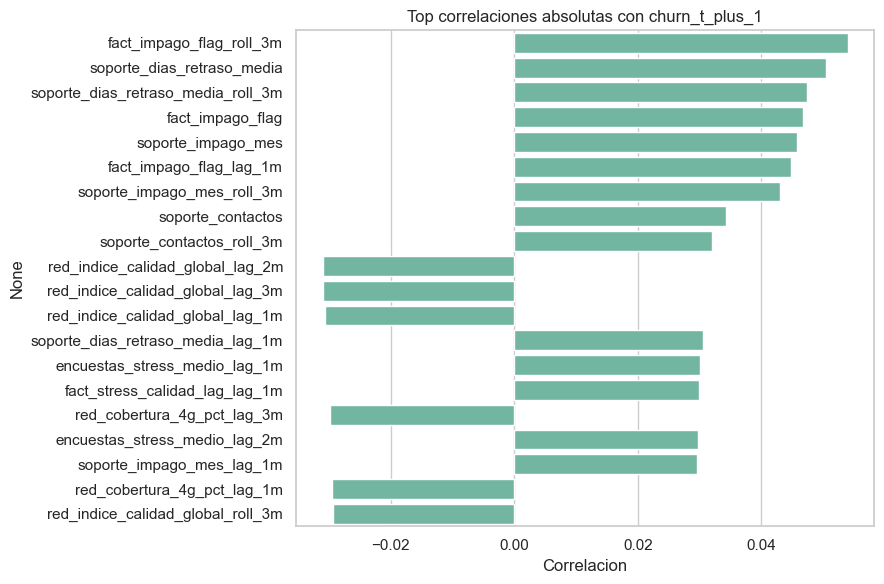

fact_impago_flag_roll_3m              0.054
soporte_dias_retraso_media            0.051
soporte_dias_retraso_media_roll_3m    0.047
fact_impago_flag                      0.047
soporte_impago_mes                    0.046
fact_impago_flag_lag_1m               0.045
soporte_impago_mes_roll_3m            0.043
soporte_contactos                     0.034
soporte_contactos_roll_3m             0.032
red_indice_calidad_global_lag_2m     -0.031
red_indice_calidad_global_lag_3m     -0.031
red_indice_calidad_global_lag_1m     -0.031
soporte_dias_retraso_media_lag_1m     0.031
encuestas_stress_medio_lag_1m         0.030
fact_stress_calidad_lag_lag_1m        0.030
red_cobertura_4g_pct_lag_3m          -0.030
encuestas_stress_medio_lag_2m         0.030
soporte_impago_mes_lag_1m             0.030
red_cobertura_4g_pct_lag_1m          -0.030
red_indice_calidad_global_roll_3m    -0.029
Name: corr_churn_t_plus_1, dtype: float64

In [8]:
num_cols = df.select_dtypes(include=[np.number]).columns.drop('churn_t_plus_1')
corr = df[num_cols].corrwith(df['churn_t_plus_1']).dropna().sort_values(key=lambda s: s.abs(), ascending=False).head(20)
plt.figure(figsize=(9, 6))
sns.barplot(x=corr.values, y=corr.index)
plt.title('Top correlaciones absolutas con churn_t_plus_1')
plt.xlabel('Correlacion')
plt.tight_layout()
plt.show()
display(corr.rename('corr_churn_t_plus_1'))


In [9]:
checks = pd.DataFrame([
    {'check': 'target sin nulos', 'ok': df['churn_t_plus_1'].notna().all()},
    {'check': 'target binario', 'ok': set(df['churn_t_plus_1'].dropna().unique()).issubset({0, 1})},
    {'check': 'sin duplicados cliente-mes', 'ok': not df.duplicated(['cliente_id','fecha']).any()},
    {'check': 'sin columna churn directa', 'ok': 'churn' not in df.columns},
    {'check': 'sin ever_churn', 'ok': 'ever_churn' not in df.columns},
])
display(checks)


,check,ok
0,target sin nulos,True
1,target binario,True
2,sin duplicados cliente-mes,True
3,sin columna churn directa,True
4,sin ever_churn,True


## Conclusiones finales

- El dataset integrado queda listo para benchmark de modelos: contiene 311987 filas, 246 columnas, 9982 clientes y 35 meses, desde 2023-01 hasta 2025-11.
- El target mensual `churn_t_plus_1` es minoritario, por lo que PR-AUC, recall, F1 y lift en top-k son mas adecuados que accuracy como metricas principales.
- Las familias de variables estan bien representadas: cliente, facturacion, red, soporte y encuestas aportan bloques diferenciados de informacion.
- Las correlaciones mas altas son moderadas, pero destacan senales coherentes con los EDA previos, como impago rolling, retrasos medios y variables de soporte/facturacion.
- Los checks estructurales revisados son favorables: target sin nulos, target binario, sin duplicados cliente-mes y sin columna de churn directa.
- El dataset puede pasar a modelado, pero la evaluacion debe ser temporal y debe vigilar falsos negativos en segmentos de alto riesgo.

## Decisiones para modelado

- Excluir `cliente_id` y `fecha` del entrenamiento.
- Usar test temporal final.
- Priorizar PR-AUC, recall de churn, F1 y lift operativo.
- Comparar aportacion incremental por familias de variables.
- Analizar falsos negativos por plan, zona, impago, soporte y antiguedad.
